# Hito 1: Last.fm - Analisis y Baselines

**Curso:** Sistemas recomendadores  
**Integrantes:** Agustin Llambias, Amaya Quero, Larry Uribe

Este notebook complementa la propuesta del Hito 1 usando el dataset real descargado desde Kaggle: `harshal19t/lastfm-dataset`.

El objetivo es formular recomendacion musical personalizada con feedback implicito: dado el historial de escuchas de un usuario, recomendar canciones futuras no escuchadas previamente.

In [1]:
from pathlib import Path
from collections import defaultdict
import math
import random

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

DATA_PATH = Path('data/Last.fm_data.csv')
TOP_K = 10
RANDOM_SEED = 42

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('Existe dataset:', DATA_PATH.exists())
print('Ruta:', DATA_PATH.resolve())

Existe dataset: True
Ruta: C:\RecSys\Proyecto-RecSys-2026-1\data\Last.fm_data.csv


## 1. Carga y normalizacion del dataset

El CSV original contiene columnas de usuario, artista, track, album, fecha y hora. Se normalizan nombres de columnas y se define `item_id` como el par `artista - track`, para distinguir canciones con el mismo titulo interpretadas por artistas distintos.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print('Shape original:', df_raw.shape)
display(df_raw.head())

music_df = df_raw.rename(columns={
    'Username': 'user_id',
    'Artist': 'artist_name',
    'Track': 'track_name',
    'Album': 'album_name',
})

music_df['item_id'] = music_df['artist_name'].astype(str) + ' - ' + music_df['track_name'].astype(str)
music_df['timestamp'] = pd.to_datetime(
    music_df['Date'].astype(str) + ' ' + music_df['Time'].astype(str),
    format='%d %b %Y %H:%M',
    errors='coerce',
)
music_df = music_df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

display(music_df.head())

Shape original: (166153, 7)


,Unnamed: 0,Username,Artist,Track,Album,Date,Time
0,0,Babs_05,Isobel Campbell,The Circus Is Leaving Town,Ballad of the Broken Seas,31 Jan 2021,23:36
1,1,Babs_05,Isobel Campbell,Dusty Wreath,Ballad of the Broken Seas,31 Jan 2021,23:32
2,2,Babs_05,Isobel Campbell,Honey Child What Can I Do?,Ballad of the Broken Seas,31 Jan 2021,23:28
3,3,Babs_05,Isobel Campbell,It's Hard To Kill A Bad Thing,Ballad of the Broken Seas,31 Jan 2021,23:25
4,4,Babs_05,Isobel Campbell,Saturday's Gone,Ballad of the Broken Seas,31 Jan 2021,23:21


,Unnamed: 0,user_id,artist_name,track_name,album_name,Date,Time,item_id,timestamp
0,16217,Babs_05,Eminem,"Lose Yourself - From ""8 Mile"" Soundtrack",8 Mile,01 Jan 2021,00:02,"Eminem - Lose Yourself - From ""8 Mile"" Soundtrack",2021-01-01 00:02:00
1,16216,Babs_05,The Game,Westside Story,The Documentary,01 Jan 2021,00:09,The Game - Westside Story,2021-01-01 00:09:00
2,16215,Babs_05,Toto,Africa,Toto IV,01 Jan 2021,00:14,Toto - Africa,2021-01-01 00:14:00
3,16214,Babs_05,Baby D,Let Me Be Your Fantasy - Radio Edit,Let Me Be Your Fantasy EP,01 Jan 2021,00:19,Baby D - Let Me Be Your Fantasy - Radio Edit,2021-01-01 00:19:00
4,16213,Babs_05,The Notorious B.I.G.,Juicy - 2005 Remaster,Ready To Die (The Remaster),01 Jan 2021,00:23,The Notorious B.I.G. - Juicy - 2005 Remaster,2021-01-01 00:23:00


## 2. Analisis descriptivo

Se revisan tamanos principales, valores faltantes, duplicados y sparsity de la matriz usuario-item.

In [3]:
stats = {
    'registros': len(music_df),
    'usuarios': music_df['user_id'].nunique(),
    'artistas': music_df['artist_name'].nunique(),
    'tracks_unicos_por_nombre': music_df['track_name'].nunique(),
    'items_artista_track': music_df['item_id'].nunique(),
    'albumes': music_df['album_name'].nunique(),
    'duplicados_exactos': int(music_df.duplicated().sum()),
    'albumes_faltantes': int(music_df['album_name'].isna().sum()),
    'timestamps_invalidos': int(music_df['timestamp'].isna().sum()),
    'fecha_minima': music_df['timestamp'].min(),
    'fecha_maxima': music_df['timestamp'].max(),
}
unique_user_items = music_df.drop_duplicates(['user_id', 'item_id'])
stats['sparsity_usuario_item'] = 1 - len(unique_user_items) / (stats['usuarios'] * stats['items_artista_track'])

display(pd.DataFrame([stats]).T.rename(columns={0: 'valor'}))

,valor
registros,166153
usuarios,11
artistas,22823
tracks_unicos_por_nombre,67241
items_artista_track,76038
albumes,38629
duplicados_exactos,0
albumes_faltantes,12
timestamps_invalidos,0
fecha_minima,2021-01-01 00:02:00


Interacciones por usuario


,valor
count,11.000000
mean,15104.818182
std,12781.392043
min,1063.000000
25%,1616.000000
50%,17230.000000
75%,23990.500000
max,33695.000000


Interacciones por item


,valor
count,76038.000000
mean,2.185131
std,3.290945
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,297.000000


C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2794142501.py:22: UserWarning: Glyph 36855 (\N{CJK UNIFIED IDEOGRAPH-8FF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2794142501.py:22: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2794142501.py:22: UserWarning: Glyph 24187 (\N{CJK UNIFIED IDEOGRAPH-5E7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2794142501.py:22: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2794142501.py:22: UserWarning: Glyph 29256 (\N{CJK UNIFIED IDEOGRAPH-7248}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2794142501.py:22: UserWarning: Tight layout n

C:\Users\larry\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36855 (\N{CJK UNIFIED IDEOGRAPH-8FF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\larry\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\larry\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24187 (\N{CJK UNIFIED IDEOGRAPH-5E7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\larry\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\larry\AppData\Local\Programs\Python

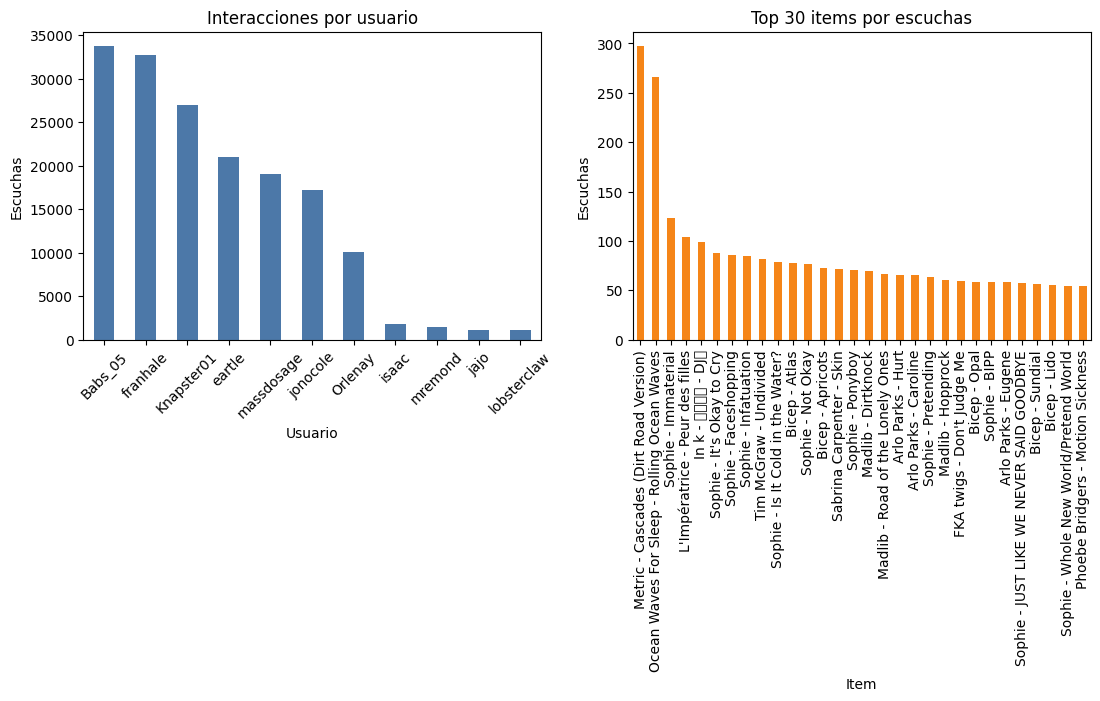

In [4]:
interacciones_usuario = music_df.groupby('user_id').size().sort_values(ascending=False)
interacciones_item = music_df.groupby('item_id').size().sort_values(ascending=False)

print('Interacciones por usuario')
display(interacciones_usuario.describe().to_frame('valor'))
print('Interacciones por item')
display(interacciones_item.describe().to_frame('valor'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
interacciones_usuario.plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('Interacciones por usuario')
axes[0].set_xlabel('Usuario')
axes[0].set_ylabel('Escuchas')
axes[0].tick_params(axis='x', labelrotation=45)

interacciones_item.head(30).plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set_title('Top 30 items por escuchas')
axes[1].set_xlabel('Item')
axes[1].set_ylabel('Escuchas')
axes[1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

Top 10 artistas


,escuchas
artist_name,
Sophie,1181
Madlib,1074
Bicep,766
Taylor Swift,649
Arlo Parks,593
Morrissey,498
Depeche Mode,469
Coldplay,393
New Order,367


Top 10 items artista-track


,escuchas
item_id,
Metric - Cascades (Dirt Road Version),297
Ocean Waves For Sleep - Rolling Ocean Waves,266
Sophie - Immaterial,123
L'Impératrice - Peur des filles,104
In k - 迷失幻境 - DJ版,99
Sophie - It's Okay to Cry,88
Sophie - Faceshopping,86
Sophie - Infatuation,85
Tim McGraw - Undivided,82


C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2136594321.py:18: UserWarning: Glyph 36855 (\N{CJK UNIFIED IDEOGRAPH-8FF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2136594321.py:18: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2136594321.py:18: UserWarning: Glyph 24187 (\N{CJK UNIFIED IDEOGRAPH-5E7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2136594321.py:18: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Temp\ipykernel_16328\2136594321.py:18: UserWarning: Glyph 29256 (\N{CJK UNIFIED IDEOGRAPH-7248}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\larry\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtool

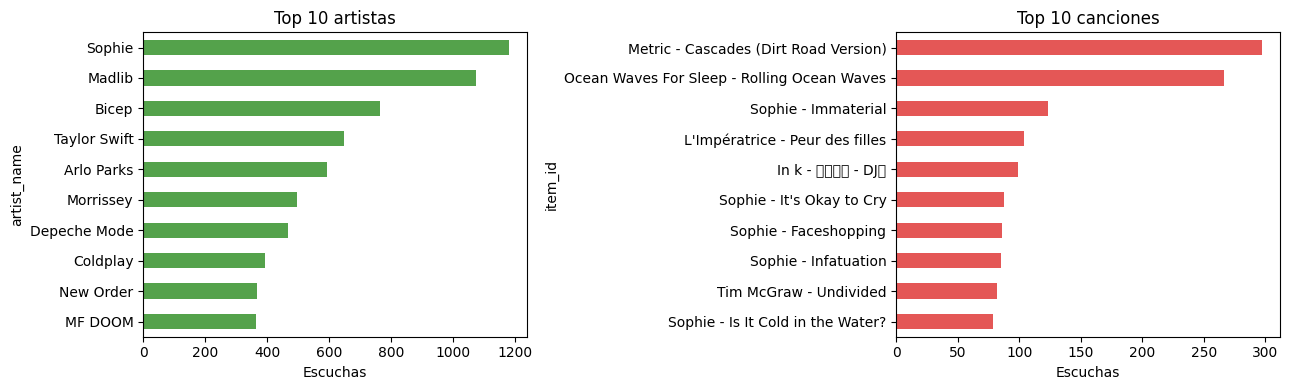

In [5]:
top_artistas = music_df['artist_name'].value_counts().head(10)
top_items = music_df['item_id'].value_counts().head(10)

print('Top 10 artistas')
display(top_artistas.to_frame('escuchas'))
print('Top 10 items artista-track')
display(top_items.to_frame('escuchas'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
top_artistas.sort_values().plot(kind='barh', ax=axes[0], color='#54A24B')
axes[0].set_title('Top 10 artistas')
axes[0].set_xlabel('Escuchas')

top_items.sort_values().plot(kind='barh', ax=axes[1], color='#E45756')
axes[1].set_title('Top 10 canciones')
axes[1].set_xlabel('Escuchas')

plt.tight_layout()
plt.show()

## 3. Protocolo de evaluacion

Se usa split temporal por usuario. Para cada usuario, el 80% inicial de sus escuchas queda en train y el 20% final en test. Los items relevantes son canciones futuras que el usuario no habia escuchado en train, lo que representa una tarea de descubrimiento.

In [6]:
def temporal_split(df, train_ratio=0.8):
    train_parts = []
    test_relevant = {}

    for user_id, user_df in df.groupby('user_id', sort=False):
        split_idx = max(1, int(len(user_df) * train_ratio))
        train_user = user_df.iloc[:split_idx]
        test_user = user_df.iloc[split_idx:]
        seen_train = set(train_user['item_id'])
        future_unseen = set(test_user['item_id']) - seen_train
        if future_unseen:
            train_parts.append(train_user)
            test_relevant[user_id] = future_unseen

    return pd.concat(train_parts, ignore_index=True), test_relevant

train_df, test_relevant = temporal_split(music_df)
print('Filas train:', len(train_df))
print('Usuarios evaluables:', len(test_relevant))
print('Items relevantes promedio por usuario:', sum(len(v) for v in test_relevant.values()) / len(test_relevant))

Filas train: 132919
Usuarios evaluables: 11
Items relevantes promedio por usuario: 2291.181818181818


## 4. Baselines

Se comparan tres modelos:

1. **Random:** recomienda canciones aleatorias no vistas.
2. **Most Popular:** recomienda las canciones mas frecuentes en train.
3. **Favorite Artist Popular:** recomienda canciones populares de los artistas mas escuchados por cada usuario, excluyendo canciones ya vistas.

In [7]:
def precision_at_k(recommended, relevant, k):
    if not recommended:
        return 0.0
    return sum(item in relevant for item in recommended[:k]) / k


def hit_rate_at_k(recommended, relevant, k):
    return float(any(item in relevant for item in recommended[:k]))


def average_precision_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    score = 0.0
    hits = 0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            hits += 1
            score += hits / rank
    return score / min(len(relevant), k)


def ndcg_at_k(recommended, relevant, k):
    dcg = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            dcg += 1.0 / math.log2(rank + 1)
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg / idcg

In [8]:
rng = random.Random(RANDOM_SEED)
users = sorted(test_relevant)
user_seen = train_df.groupby('user_id')['item_id'].apply(set).to_dict()
popular_items = train_df['item_id'].value_counts().index.tolist()
catalog = sorted(train_df['item_id'].unique())

artist_popular_items = {
    artist: artist_df['item_id'].value_counts().index.tolist()
    for artist, artist_df in train_df.groupby('artist_name')
}
user_artist_profile = {
    user_id: user_df['artist_name'].value_counts()
    for user_id, user_df in train_df.groupby('user_id')
}


def recommend_random(user, k=TOP_K):
    seen = user_seen[user]
    candidates = [item for item in catalog if item not in seen]
    return rng.sample(candidates, min(k, len(candidates)))


def recommend_most_popular(user, k=TOP_K):
    seen = user_seen[user]
    return [item for item in popular_items if item not in seen][:k]


def recommend_favorite_artist(user, k=TOP_K):
    seen = set(user_seen[user])
    recommendations = []
    for artist in user_artist_profile[user].index:
        for item in artist_popular_items.get(artist, []):
            if item not in seen:
                recommendations.append(item)
                seen.add(item)
                if len(recommendations) == k:
                    return recommendations
    for item in popular_items:
        if item not in seen:
            recommendations.append(item)
            seen.add(item)
            if len(recommendations) == k:
                break
    return recommendations

In [9]:
recommenders = {
    'Random': recommend_random,
    'Most Popular': recommend_most_popular,
    'Favorite Artist Popular': recommend_favorite_artist,
}

rows = []
for model_name, recommender in recommenders.items():
    metrics = defaultdict(float)
    for user in users:
        relevant = test_relevant[user]
        recs = recommender(user)
        metrics['HitRate@10'] += hit_rate_at_k(recs, relevant, TOP_K)
        metrics['Precision@10'] += precision_at_k(recs, relevant, TOP_K)
        metrics['MAP@10'] += average_precision_at_k(recs, relevant, TOP_K)
        metrics['nDCG@10'] += ndcg_at_k(recs, relevant, TOP_K)

    rows.append({'Modelo': model_name, **{m: v / len(users) for m, v in metrics.items()}})

results_df = pd.DataFrame(rows).sort_values('nDCG@10', ascending=False)
display(results_df)

results_df.to_csv('resultados_hito1_lastfm.csv', index=False)
print('Resultados guardados en resultados_hito1_lastfm.csv')

,Modelo,HitRate@10,Precision@10,MAP@10,nDCG@10
2,Favorite Artist Popular,0.454545,0.063636,0.017965,0.057377
1,Most Popular,0.090909,0.045455,0.020159,0.036749
0,Random,0.363636,0.036364,0.007449,0.030956


Resultados guardados en resultados_hito1_lastfm.csv


## 5. Discusion preliminar

El baseline **Favorite Artist Popular** obtiene el mejor nDCG@10 y HitRate@10, lo que indica que las preferencias historicas por artista son una senal util para personalizar recomendaciones. **Most Popular** mantiene buen MAP@10, mostrando que la popularidad global sigue siendo competitiva para ordenar algunos aciertos tempranos. **Random** sirve como control minimo y confirma que la evaluacion no esta trivialmente saturada.

Para el Midterm, el siguiente paso natural es implementar filtrado colaborativo item-item o factorizacion matricial con feedback implicito, cuidando cobertura y ranking top-K.